
---
**Dataset:** FIFA 17 + FIFA 18 combinados  
**m (filas):** 35,487 jugadores  
**n (features):** 40 variables numéricas  
**Variable objetivo:** `élite` → 1 si Overall ≥ 80, 0 si no

##  Paso 1: Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Paso 2: Importar librerías

In [ ]:
# Manejo de rutas y directorios
import os

# Cálculo científico y vectorial
import numpy as np

# Manejo de datos
import pandas as pd

# Librerías para graficar
from matplotlib import pyplot
import matplotlib.pyplot as plt

# Módulo de optimización de scipy
from scipy import optimize

# Incrusta gráficos en el cuaderno
%matplotlib inline

print(' Librerías importadas correctamente')

 Librerías importadas correctamente


##  Paso 3: Cargar el Dataset

In [ ]:
# Ruta del dataset en Google Drive
RUTA = '/content/drive/MyDrive/Universida/IA/Dataset/Clasificacion/FIFA_17_18_combined.csv'

# Cargar el dataset
df = pd.read_csv(RUTA)

print(f'Dataset cargado correctamente')
print(f'Total filas: {df.shape[0]}')
print(f'Total columnas: {df.shape[1]}')
df.head(3)

Dataset cargado correctamente
Total filas: 35487
Total columnas: 65


,Curve,GKPositioning,Crossing,Club,Overall,Age,Composure,SprintSpeed,International Reputation,Reactions,...,Preferred Foot,Name,Balance,Work Rate,Contract Valid Until,ShotPower,GKReflexes,Marking,Loaned From,FIFA_Year.1
0,86.0,33.0,77.0,FC Barcelona,92,29,83.0,77.0,5.0,93.0,...,Right,L. Suárez,60.0,High/ Medium,2021,87.0,37.0,30.0,NaN,17
1,73.0,8.0,73.0,Roma,86,28,85.0,78.0,3.0,87.0,...,Right,R. Nainggolan,84.0,High/ High,2021,84.0,11.0,78.0,NaN,17
2,76.0,2.0,76.0,FC Bayern München,87,29,86.0,74.0,4.0,89.0,...,Right,A. Vidal,77.0,High/ High,2019,84.0,4.0,76.0,NaN,17


##  Paso 4: Preparar los datos

In [ ]:
# Seleccionar las 40 features numéricas relevantes
features = [
    'Age', 'Potential', 'Crossing', 'Finishing', 'HeadingAccuracy',
    'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
    'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed',
    'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping',
    'Stamina', 'Strength', 'LongShots', 'Aggression', 'Interceptions',
    'Positioning', 'Vision', 'Penalties', 'Composure', 'Marking',
    'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling',
    'GKKicking', 'GKPositioning', 'GKReflexes',
    'International Reputation', 'Weak Foot', 'Skill Moves', 'FIFA_Year'
]

# Limpiar datos (eliminar filas con nulos)
df_clean = df[features + ['Overall']].dropna()

# Variable objetivo binaria: 1 = Élite (Overall >= 80), 0 = No élite
y = (df_clean['Overall'] >= 80).astype(int).values

# Features (X)
X = df_clean[features].values

print(f' Features (n): {X.shape[1]}')
print(f' Muestras  (m): {X.shape[0]}')
print(f' Jugadores élite    (y=1): {y.sum():,}')
print(f' Jugadores no élite (y=0): {(y==0).sum():,}')

 Features (n): 40
 Muestras  (m): 35487
 Jugadores élite    (y=1): 1,054
 Jugadores no élite (y=0): 34,433


## Paso 5: Visualizar los datos
Graficamos las dos features más correlacionadas con ser élite: **Reactions** vs **Potential**

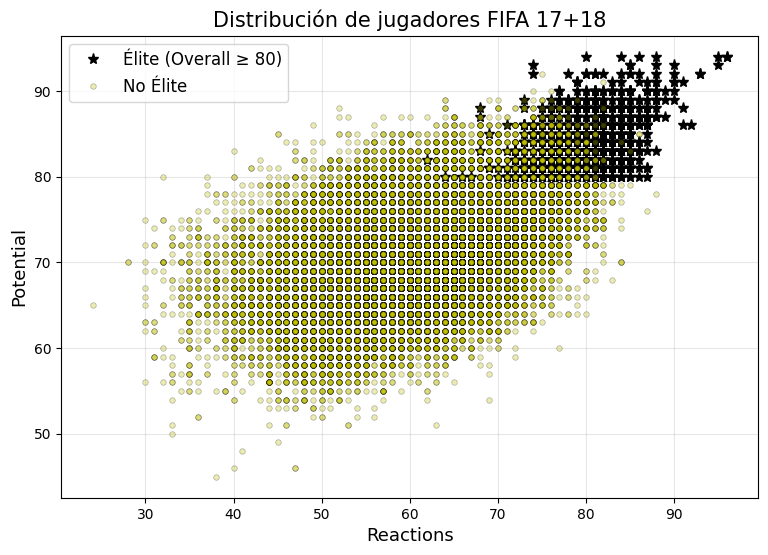

In [ ]:
def plotData(X, y, feat1_idx, feat2_idx, feat1_name, feat2_name):
    """
    Grafica los puntos de datos X y y.
    * = jugadores élite (y=1)
    o = jugadores no élite (y=0)
    """
    fig = pyplot.figure(figsize=(9, 6))

    pos = y == 1
    neg = y == 0

    pyplot.plot(X[pos, feat1_idx], X[pos, feat2_idx], 'k*', lw=2, ms=8, label='Élite (Overall ≥ 80)')
    pyplot.plot(X[neg, feat1_idx], X[neg, feat2_idx], 'ko', mfc='y', ms=4, mec='k', mew=0.5, alpha=0.3, label='No Élite')
    pyplot.xlabel(feat1_name, fontsize=13)
    pyplot.ylabel(feat2_name, fontsize=13)
    pyplot.title('Distribución de jugadores FIFA 17+18', fontsize=15)
    pyplot.legend(fontsize=12)
    pyplot.grid(True, alpha=0.3)

# Graficar Reactions vs Potential
feat1_idx = features.index('Reactions')
feat2_idx = features.index('Potential')

plotData(X, y, feat1_idx, feat2_idx, 'Reactions', 'Potential')
pyplot.show()

## Paso 6: Función Sigmoide

Prueba de la función Sigmoide:
  sigmoid(  -100) = 0.000000
  sigmoid(    -1) = 0.268941
  sigmoid(     0) = 0.500000
  sigmoid(   0.5) = 0.622459
  sigmoid(     1) = 0.731059
  sigmoid(   100) = 1.000000


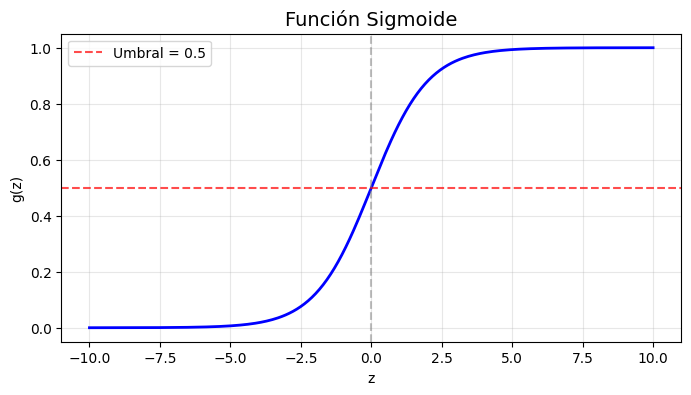

In [ ]:
def sigmoid(z):
    """
    Calcula la sigmoide de una entrada z.
    Convierte cualquier valor real en una probabilidad entre 0 y 1.
    """
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Prueba de la función sigmoide
z_test = [-100, -1, 0, 0.5, 1, 100]
print('Prueba de la función Sigmoide:')
for z in z_test:
    print(f'  sigmoid({z:6}) = {sigmoid(z):.6f}')

# Graficar la función sigmoide
z_range = np.linspace(-10, 10, 300)
pyplot.figure(figsize=(8, 4))
pyplot.plot(z_range, sigmoid(z_range), 'b-', lw=2)
pyplot.axhline(0.5, color='r', linestyle='--', alpha=0.7, label='Umbral = 0.5')
pyplot.axvline(0, color='gray', linestyle='--', alpha=0.5)
pyplot.title('Función Sigmoide', fontsize=14)
pyplot.xlabel('z')
pyplot.ylabel('g(z)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.show()

## Paso 7: Preparar la matriz X con término de intercepción

In [ ]:
# Normalizar X para mejor convergencia del gradiente
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-8   # evitar división por cero
X_norm = (X - X_mean) / X_std

m, n = X_norm.shape

# Agregar término de intercepción (columna de unos)
X_bias = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f' X con intercepción: {X_bias.shape}  (m={m}, n+1={X_bias.shape[1]})')

 X con intercepción: (35487, 41)  (m=35487, n+1=41)


## Paso 8: Función de Costo

In [ ]:
def calcularCosto(theta, X, y):
    """
    Calcula el costo de la regresión logística.
    J = -(1/m) * sum( y*log(h) + (1-y)*log(1-h) )
    """
    m = y.size
    h = sigmoid(X.dot(theta.T))
    # Clip para evitar log(0)
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return J

# Probar con theta inicial en ceros
theta_inicial = np.zeros(n + 1)
costo_inicial = calcularCosto(theta_inicial, X_bias, y)
print(f'Costo con theta inicial (ceros): {costo_inicial:.4f}')
print(f'Costo esperado (aprox.): 0.6931')

Costo con theta inicial (ceros): 0.6931
Costo esperado (aprox.): 0.6931


##  Paso 9: Descenso por el Gradiente

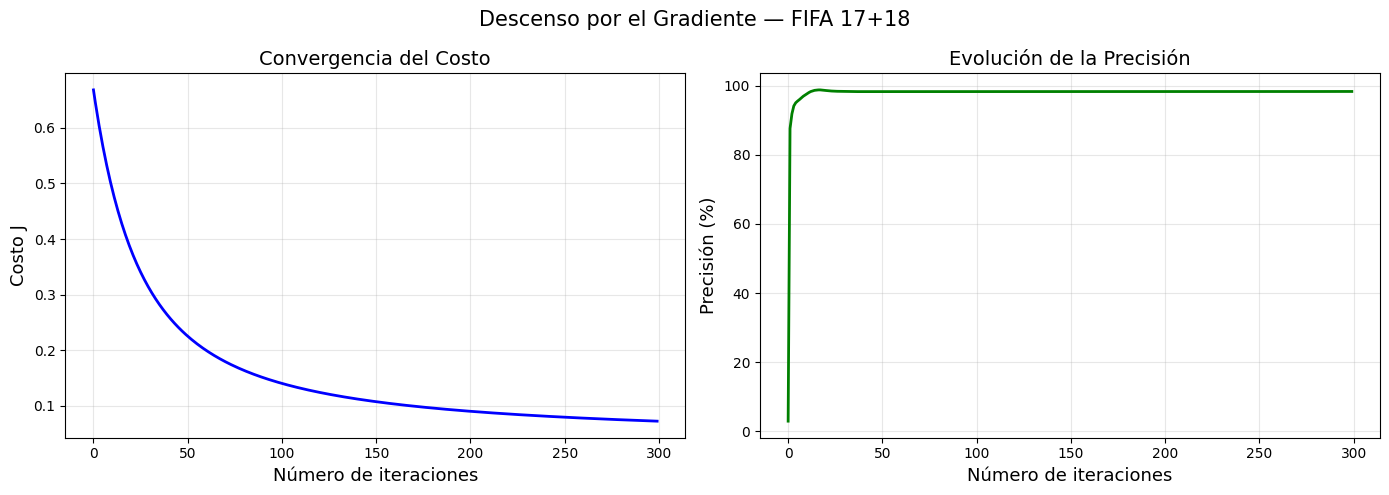

Costo final:     0.0722
Precisión final: 98.31 %
Primeros 5 valores de theta: [-3.1517505  -0.07115235  0.28275415 -0.034984    0.01858589]


In [ ]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    """
    Ejecuta el descenso por el gradiente para minimizar J(theta).
    Actualización: theta = theta - (alpha/m) * X^T * (h - y)
    """
    m = y.shape[0]
    theta = theta.copy()
    J_history         = []
    precision_history = []  #

    for i in range(num_iters):
        h     = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))

        # Precisión: y_inferido == y_real
        y_inferido = (h >= 0.5).astype(int)
        precision  = np.mean(y_inferido == y) * 100
        precision_history.append(precision)   # ←

    return theta, J_history, precision_history  #

# Parámetros
alpha     = 0.1
num_iters = 300

theta_inicial = np.zeros(n + 1)
theta_gd, J_history, precision_history = descensoGradiente(  #
    theta_inicial, X_bias, y, alpha, num_iters
)

# Graficar Costo y Precisión juntos
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Costo J
ax1.plot(np.arange(len(J_history)), J_history, 'b-', lw=2)
ax1.set_xlabel('Número de iteraciones', fontsize=13)
ax1.set_ylabel('Costo J',              fontsize=13)
ax1.set_title('Convergencia del Costo', fontsize=14)
ax1.grid(True, alpha=0.3)

# Gráfica 2: Precisión
ax2.plot(np.arange(len(precision_history)), precision_history, 'g-', lw=2)
ax2.set_xlabel('Número de iteraciones', fontsize=13)
ax2.set_ylabel('Precisión (%)',         fontsize=13)
ax2.set_title('Evolución de la Precisión', fontsize=14)
ax2.grid(True, alpha=0.3)

pyplot.suptitle('Descenso por el Gradiente — FIFA 17+18', fontsize=15)
pyplot.tight_layout()
pyplot.show()

print(f'Costo final:     {J_history[-1]:.4f}')
print(f'Precisión final: {precision_history[-1]:.2f} %')
print(f'Primeros 5 valores de theta: {theta_gd[:5]}')

##  Paso 10: Optimización con scipy (TNC)

In [ ]:
def costFunction(theta, X, y):
    """
    Calcula el costo Y el gradiente juntos (requerido por scipy.optimize).
    Retorna: (J, grad)
    """
    m = y.size
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J    = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    grad = (1 / m) * X.T.dot(h - y)
    return J, grad

# Opciones de optimización
options = {'maxiter': 1000}

initial_theta = np.zeros(n + 1)

# Optimización con método TNC (Newton Truncado)
res = optimize.minimize(
    costFunction,
    initial_theta,
    (X_bias, y),
    jac=True,
    method='TNC',
    options=options
)

cost_opt  = res.fun
theta_opt = res.x

print(f' Costo con optimize.minimize (TNC): {cost_opt:.4f}')
print(f'Primeros 5 valores de theta optimizado: {theta_opt[:5]}')

/tmp/ipykernel_809/1746765473.py:19: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(


 Costo con optimize.minimize (TNC): 0.0164
Primeros 5 valores de theta optimizado: [-20.00547977   2.97921189   6.25929244  -0.04009582  -0.02169948]


##  Paso 11: Predicción y Precisión

In [ ]:
def predict(theta, X):
    """
    Predice 0 o 1 usando un umbral de 0.5.
    Si sigmoid(theta^T * x) >= 0.5 → predice 1 (élite)
    """
    m = X.shape[0]
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

# Predicciones con theta del descenso por gradiente
p_gd = predict(theta_gd, X_bias)
acc_gd = np.mean(p_gd == y) * 100

# Predicciones con theta optimizado (TNC)
p_opt = predict(theta_opt, X_bias)
acc_opt = np.mean(p_opt == y) * 100


print(f' Precisión (Descenso Gradiente): {acc_gd:.2f} %')
print(f' Precisión (Optimización TNC):   {acc_opt:.2f} %')


 Precisión (Descenso Gradiente): 98.31 %
 Precisión (Optimización TNC):   99.28 %


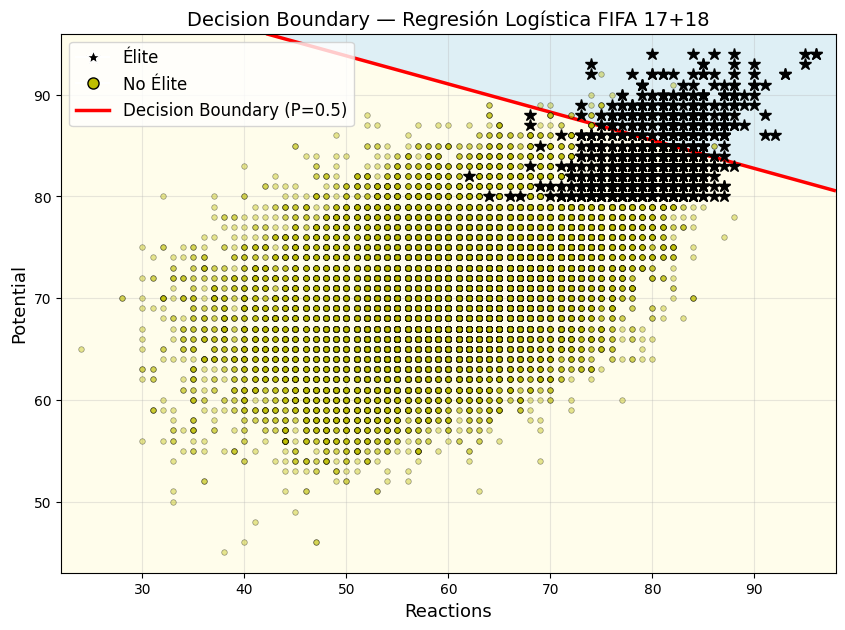

In [ ]:
## 📐 Paso 5.1: Decision Boundary (Límite de Decisión)
# Se grafican SOLO las 2 features más importantes para visualizar la frontera
# Reactions (eje X) vs Potential (eje Y)

from matplotlib.colors import ListedColormap

reactions_idx = features.index('Reactions')
potential_idx = features.index('Potential')

# Crear grilla de valores para las 2 features
x1_min, x1_max = X[:, reactions_idx].min() - 2, X[:, reactions_idx].max() + 2
x2_min, x2_max = X[:, potential_idx].min()  - 2, X[:, potential_idx].max() + 2

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                        np.linspace(x2_min, x2_max, 200))

# Para cada punto de la grilla, crear un vector con las 40 features
# Las demás features se fijan en su valor promedio (X_mean)
X_grid = np.tile(X_mean, (xx1.ravel().shape[0], 1))
X_grid[:, reactions_idx] = xx1.ravel()
X_grid[:, potential_idx]  = xx2.ravel()

# Normalizar la grilla
X_grid_norm = (X_grid - X_mean) / X_std

# Agregar intercepción
X_grid_bias = np.concatenate([np.ones((X_grid_norm.shape[0], 1)), X_grid_norm], axis=1)

# Predecir probabilidades sobre la grilla
Z = sigmoid(X_grid_bias.dot(theta_opt)).reshape(xx1.shape)

# --- Graficar ---
pyplot.figure(figsize=(10, 7))

pos = y == 1
neg = y == 0

# Fondo con regiones de clasificación
pyplot.contourf(xx1, xx2, Z, levels=[0, 0.5, 1],
                colors=['#FFFACD', '#ADD8E6'], alpha=0.4)

# Línea de decisión (donde P = 0.5)
pyplot.contour(xx1, xx2, Z, levels=[0.5],
               colors='red', linewidths=2.5)

# Puntos de datos
pyplot.plot(X[neg, reactions_idx], X[neg, potential_idx],
            'ko', mfc='y', ms=4, mec='k', mew=0.5, alpha=0.4, label='No Élite')
pyplot.plot(X[pos, reactions_idx], X[pos, potential_idx],
            'k*', ms=9, lw=2, label='Élite (Overall ≥ 80)')

# Línea manual de leyenda para la frontera
from matplotlib.lines import Line2D
legend_boundary = Line2D([0], [0], color='red', lw=2.5, label='Decision Boundary (P=0.5)')

pyplot.xlabel('Reactions', fontsize=13)
pyplot.ylabel('Potential', fontsize=13)
pyplot.title('Decision Boundary — Regresión Logística FIFA 17+18', fontsize=14)
pyplot.legend(handles=[
    pyplot.matplotlib.lines.Line2D([0],[0], marker='*', color='w',
        markerfacecolor='k', ms=10, label='Élite'),
    pyplot.matplotlib.lines.Line2D([0],[0], marker='o', color='w',
        markerfacecolor='y', markeredgecolor='k', ms=8, label='No Élite'),
    legend_boundary
], fontsize=12)
pyplot.grid(True, alpha=0.3)
pyplot.show()


##  Paso 12: Predicción para un jugador específico

In [ ]:
def predecir_jugador(stats_jugador, features, X_mean, X_std, theta):
    """
    Predice si un jugador es élite dado sus estadísticas.
    stats_jugador: diccionario con los valores de cada feature
    """
    x = np.array([stats_jugador[f] for f in features])
    x_norm = (x - X_mean) / X_std
    x_bias = np.concatenate([[1], x_norm])
    prob = sigmoid(np.dot(x_bias, theta))
    return prob

# Ejemplo 1: Jugador con stats altas (posible élite)
jugador_bueno = {
    'Age': 27, 'Potential': 88, 'Crossing': 80, 'Finishing': 85,
    'HeadingAccuracy': 78, 'ShortPassing': 83, 'Volleys': 79,
    'Dribbling': 85, 'Curve': 80, 'FKAccuracy': 75, 'LongPassing': 78,
    'BallControl': 86, 'Acceleration': 82, 'SprintSpeed': 80,
    'Agility': 83, 'Reactions': 85, 'Balance': 80, 'ShotPower': 82,
    'Jumping': 75, 'Stamina': 80, 'Strength': 76, 'LongShots': 80,
    'Aggression': 70, 'Interceptions': 40, 'Positioning': 85,
    'Vision': 82, 'Penalties': 78, 'Composure': 84, 'Marking': 38,
    'StandingTackle': 35, 'SlidingTackle': 33, 'GKDiving': 10,
    'GKHandling': 10, 'GKKicking': 10, 'GKPositioning': 10,
    'GKReflexes': 10, 'International Reputation': 4,
    'Weak Foot': 4, 'Skill Moves': 4, 'FIFA_Year': 18
}

prob1 = predecir_jugador(jugador_bueno, features, X_mean, X_std, theta_opt)
print(f'Jugador con stats altas:')
print(f'  Probabilidad de ser Élite: {prob1*100:.1f}%')
print(f'  Clasificación: {" ÉLITE" if prob1 >= 0.5 else " No Élite"}')

print()

# Ejemplo 2: Jugador con stats bajas
jugador_regular = {
    'Age': 22, 'Potential': 68, 'Crossing': 55, 'Finishing': 50,
    'HeadingAccuracy': 52, 'ShortPassing': 60, 'Volleys': 48,
    'Dribbling': 58, 'Curve': 52, 'FKAccuracy': 45, 'LongPassing': 55,
    'BallControl': 60, 'Acceleration': 65, 'SprintSpeed': 63,
    'Agility': 62, 'Reactions': 60, 'Balance': 60, 'ShotPower': 58,
    'Jumping': 60, 'Stamina': 65, 'Strength': 62, 'LongShots': 50,
    'Aggression': 55, 'Interceptions': 50, 'Positioning': 52,
    'Vision': 55, 'Penalties': 50, 'Composure': 58, 'Marking': 52,
    'StandingTackle': 55, 'SlidingTackle': 53, 'GKDiving': 8,
    'GKHandling': 8, 'GKKicking': 8, 'GKPositioning': 8,
    'GKReflexes': 8, 'International Reputation': 1,
    'Weak Foot': 2, 'Skill Moves': 2, 'FIFA_Year': 17
}

prob2 = predecir_jugador(jugador_regular, features, X_mean, X_std, theta_opt)
print(f'Jugador con stats bajas:')
print(f'  Probabilidad de ser Élite: {prob2*100:.1f}%')
print(f'  Clasificación: {" ÉLITE" if prob2 >= 0.5 else " No Élite"}')

Jugador con stats altas:
  Probabilidad de ser Élite: 100.0%
  Clasificación:  ÉLITE

Jugador con stats bajas:
  Probabilidad de ser Élite: 0.0%
  Clasificación:  No Élite


##  Paso 13: Matriz de Confusión

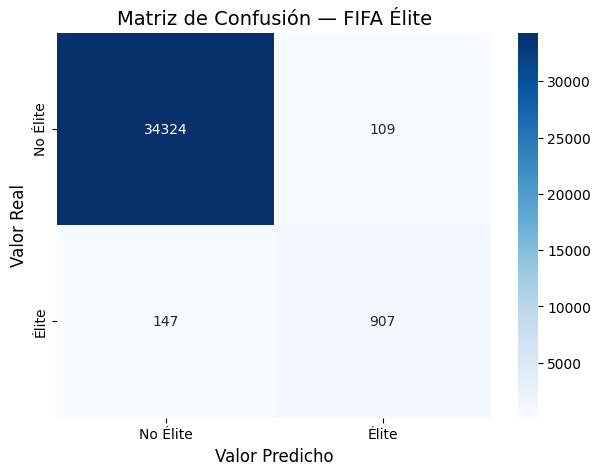


Reporte de Clasificación:
              precision    recall  f1-score   support

    No Élite       1.00      1.00      1.00     34433
       Élite       0.89      0.86      0.88      1054

    accuracy                           0.99     35487
   macro avg       0.94      0.93      0.94     35487
weighted avg       0.99      0.99      0.99     35487



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Usar predicciones del modelo optimizado
cm = confusion_matrix(y, p_opt)

pyplot.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Élite', 'Élite'],
            yticklabels=['No Élite', 'Élite'])
pyplot.title('Matriz de Confusión — FIFA Élite', fontsize=14)
pyplot.ylabel('Valor Real', fontsize=12)
pyplot.xlabel('Valor Predicho', fontsize=12)
pyplot.show()

print('\nReporte de Clasificación:')
print(classification_report(y, p_opt, target_names=['No Élite', 'Élite']))

##  Paso 14: Curva ROC y AUC

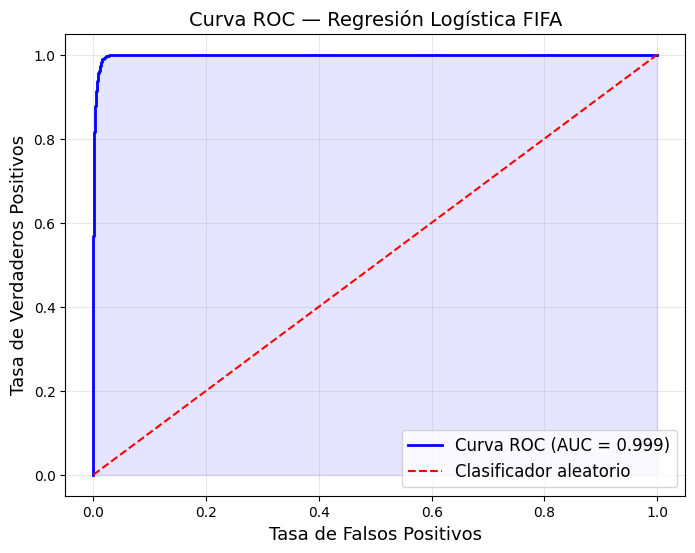


✅ AUC = 0.9986
   (1.0 = perfecto, 0.5 = aleatorio)


In [ ]:
from sklearn.metrics import roc_curve, auc

# Probabilidades predichas (no solo 0/1)
y_prob = sigmoid(X_bias.dot(theta_opt))

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

pyplot.figure(figsize=(8, 6))
pyplot.plot(fpr, tpr, 'b-', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
pyplot.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Clasificador aleatorio')
pyplot.fill_between(fpr, tpr, alpha=0.1, color='blue')
pyplot.xlabel('Tasa de Falsos Positivos', fontsize=13)
pyplot.ylabel('Tasa de Verdaderos Positivos', fontsize=13)
pyplot.title('Curva ROC — Regresión Logística FIFA', fontsize=14)
pyplot.legend(loc='lower right', fontsize=12)
pyplot.grid(True, alpha=0.3)
pyplot.show()

print(f'\n AUC = {roc_auc:.4f}')
print('   (1.0 = perfecto, 0.5 = aleatorio)')

##  Paso 15: Features más importantes

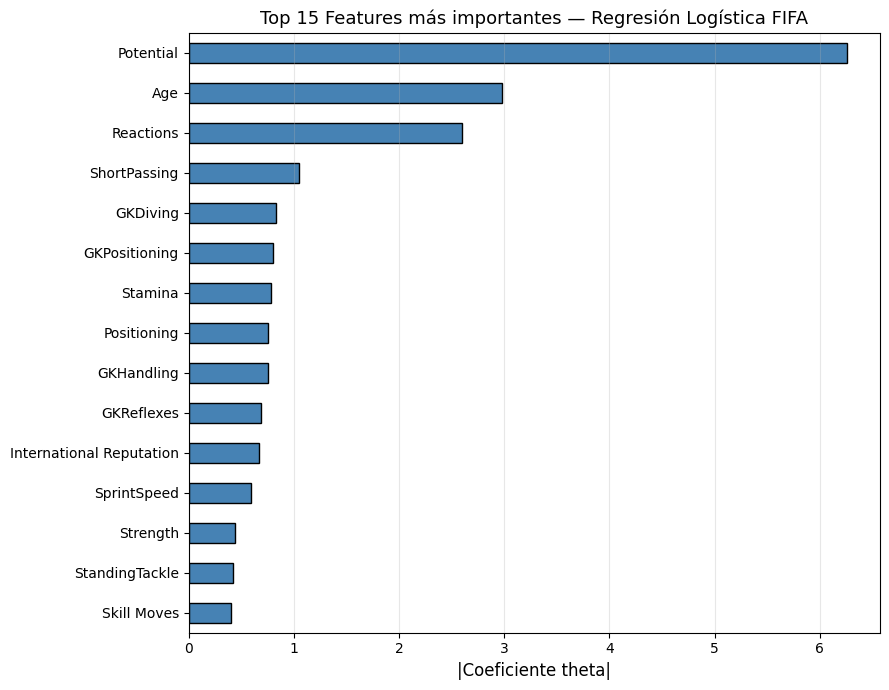


Top 10 features más influyentes:
Potential        6.259292
Age              2.979212
Reactions        2.601851
ShortPassing     1.047463
GKDiving         0.828354
GKPositioning    0.799812
Stamina          0.784149
Positioning      0.754385
GKHandling       0.752497
GKReflexes       0.684078


In [ ]:
# Los coeficientes de theta indican la importancia de cada feature
importancias = pd.Series(np.abs(theta_opt[1:]), index=features)
importancias = importancias.sort_values(ascending=True).tail(15)

pyplot.figure(figsize=(9, 7))
importancias.plot(kind='barh', color='steelblue', edgecolor='black')
pyplot.title('Top 15 Features más importantes — Regresión Logística FIFA', fontsize=13)
pyplot.xlabel('|Coeficiente theta|', fontsize=12)
pyplot.grid(True, alpha=0.3, axis='x')
pyplot.tight_layout()
pyplot.show()

print('\nTop 10 features más influyentes:')
print(importancias.sort_values(ascending=False).head(10).to_string())

##  Paso 16: Resumen Final

In [ ]:
print('=' * 60)
print('        RESUMEN — REGRESIÓN LOGÍSTICA FIFA 17+18')
print('=' * 60)
print(f'  Dataset:         FIFA 17 + FIFA 18 combinados')
print(f'  Muestras (m):    {X.shape[0]:,}')
print(f'  Features (n):    {X.shape[1]}')
print(f'  Variable obj.:   Élite si Overall >= 80')
print(f'  Jugadores élite: {y.sum():,} ({y.mean()*100:.1f}%)')
print('-' * 60)
print(f'  Costo inicial:              {calcularCosto(np.zeros(n+1), X_bias, y):.4f}')
print(f'  Costo final (Gradiente):    {J_history[-1]:.4f}')
print(f'  Costo final (TNC):          {cost_opt:.4f}')
print('-' * 60)
print(f'  Precisión (Gradiente):      {acc_gd:.2f} %')
print(f'  Precisión (TNC):            {acc_opt:.2f} %')
print(f'  AUC:                        {roc_auc:.4f}')
print('=' * 60)

        RESUMEN — REGRESIÓN LOGÍSTICA FIFA 17+18
  Dataset:         FIFA 17 + FIFA 18 combinados
  Muestras (m):    35,487
  Features (n):    40
  Variable obj.:   Élite si Overall >= 80
  Jugadores élite: 1,054 (3.0%)
------------------------------------------------------------
  Costo inicial:              0.6931
  Costo final (Gradiente):    0.0722
  Costo final (TNC):          0.0164
------------------------------------------------------------
  Precisión (Gradiente):      98.31 %
  Precisión (TNC):            99.28 %
  AUC:                        0.9986
